In [1]:
import numpy as np
from utils.load_preprocess import load_preprocess
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, RocCurveDisplay, roc_auc_score
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

# Initialize rng
rng = np.random.default_rng(2022)

# # Genes
# selecting top 100 genes gives 81 from feature selection using stability
# selecting top 500 genes gives 4111 from feature selection using stability
n_genes = 100

In [2]:
X = load_preprocess(n_genes, as_df=True)
y = X['class'].to_numpy()
X.drop('class', 1, inplace=True)
neg_pos_ratio = np.count_nonzero(y == 0)/np.count_nonzero(y==1)

In [3]:
# # Split into train, validation, and test
# X_train_val, X_test, y_train_val, y_test = train_test_split(X,
#                                                         y,
#                                                         stratify=y,
#                                                         test_size=0.2,
#                                                         random_state=rng.integers(500000))
# X_train, X_val, y_train, y_val = train_test_split(X_train_val,
#                                                 y_train_val,
#                                                 stratify=y_train_val,
#                                                 test_size=0.2,
#                                                 random_state=rng.integers(500000))

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
AUROC: 0.7740719696969696 [CI 0.6174242424242424 - 0.9053030303030303]


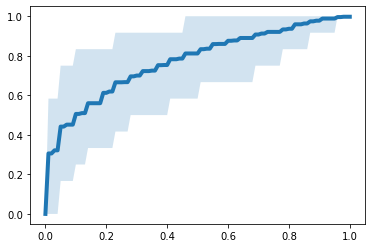

In [4]:
# # times to run bootstrap
n_bootstrap = 100

# # of hyperparameter combinations to try in random search
n_combinations = 1000

# Build an FPR grid to generate TPR on a grid
fpr_grid_vec = np.linspace(0, 1, 101, endpoint=True)
tpr_grid_mat = np.zeros((len(fpr_grid_vec), n_bootstrap))

# Maintain a list of AUROC scores
auroc_list = []
best_auroc_yet = 0.0
best_model_yet = None


for i in range(n_bootstrap):
    print(i)
    # Split into train, validation, and test
    X_train_val, X_test, y_train_val, y_test = train_test_split(X,
                                                            y,
                                                            stratify=y,
                                                            test_size=0.2,
                                                            random_state=rng.integers(500000))
    X_train, X_val, y_train, y_val = train_test_split(X_train_val,
                                                    y_train_val,
                                                    stratify=y_train_val,
                                                    test_size=0.2,
                                                    random_state=rng.integers(500000))
    
    # Hyperparameter tuning
    prev_best_auroc = 0.0
    prev_best_test_pred = None
    prev_best_model = None
    for j in range(n_combinations):
        
        # Generate random values for hyperparameters
        # Generate learning rate between 0-0.7
        eta = rng.random()*0.7 + 0.01 
        # Generate max_depth between 3-10
        max_depth = rng.integers(low=3, high=11)
        # Generate min_child_weight between 1-10
        min_child_weight = rng.integers(low=1, high=11)
        # Generate subsample between 0.5-1
        subsample = 0.5 + rng.random()*0.5
        # Generate reg_lambda between 0.1 and 1000.1
        reg_lambda = 0.1 + 1000*rng.random()
        # Generate reg_alpha between 0.001 and 1000.001
        reg_alpha = 0.001 + 1000*rng.random()
        # Generate colsample_by between 0.5 and 1
        colsample_by = 0.5 + rng.random()*0.5
    
        model = XGBClassifier(eta=eta,
                              max_depth=max_depth,
                              min_child_weight=min_child_weight,
                              subsample=subsample,
                              reg_lambda=reg_lambda,
                              reg_alpha=reg_alpha,
                              scale_pos_weight=neg_pos_ratio,
                              colsample_by=colsample_by,
                              verbosity=0)
        # Fit on training data
        model.fit(X_train, y_train)

        # Get predictions on validation set
        y_pred = model.predict_proba(X_val)

        # Calculate AUROC
        auroc = roc_auc_score(y_val, y_pred[:,1])

        # Save if this is the best model
        if auroc > prev_best_auroc:
            # Save the latest best AUROC
            prev_best_auroc = auroc
            # Save the predictions of this model for the test set
            prev_best_test_pred = model.predict_proba(X_test)
            prev_best_model = model
                            
    if prev_best_auroc > best_auroc_yet:
        best_auroc_yet = prev_best_auroc
        best_model_yet = prev_best_model
        
    fpr, tpr, _ = roc_curve(y_true=y_test, y_score=prev_best_test_pred[:,1])
    fpr = np.concatenate(([0], fpr, [1]))
    tpr = np.concatenate(([0], tpr, [1]))

    interpolator = interp1d(fpr, tpr, kind='nearest')

    tpr_grid_mat[:, i] = interpolator(fpr_grid_vec)

    auroc_list.append(roc_auc_score(y_test, prev_best_test_pred[:,1]))
    
# confidence interval for AUCs
sorted_scores = np.array(auroc_list)
sorted_scores.sort()
auroc_mean = np.mean(sorted_scores)
confidence_lower = sorted_scores[int(0.05 * len(sorted_scores))]
confidence_upper = sorted_scores[int(0.95 * len(sorted_scores))]
print('AUROC: {} [CI {} - {}]'.format(auroc_mean, confidence_lower, confidence_upper))

# Plot
# confidence interval for ROC
tpr_grid_mats = np.sort(tpr_grid_mat, axis=1)
tpr_low_05 = tpr_grid_mats[:, int(0.05 * n_bootstrap)]
tpr_top_95 = tpr_grid_mats[:, int(0.95 * n_bootstrap)]
tpr_mean = np.mean(tpr_grid_mat, axis=1)

# plt.hold(True)
ax = plt.gca()  # kwargs.pop('ax', plt.gca())
base_line, = ax.plot(fpr_grid_vec, tpr_mean, '-', linewidth=4)
ax.fill_between(fpr_grid_vec, tpr_low_05, tpr_top_95, facecolor=base_line.get_color(), alpha=0.2);

# Interpretation

In [5]:
import xgboost
import shap

In [6]:
# # importance by weight
# _, ax_weight = plt.subplots(figsize=(12,12))
# xgboost.plot_importance(best_model_yet, ax=ax_weight)
# plt.title("xgboost.plot_importance(model)");

In [7]:
# # importance by gain
# _, ax_gain = plt.subplots(figsize=(12,12))
# xgboost.plot_importance(best_model_yet, importance_type='gain', ax=ax_gain)
# plt.title("xgboost.plot_importance(model)");

In [8]:
# # importance by cover
# _, ax_cover = plt.subplots(figsize=(12,12))
# xgboost.plot_importance(best_model_yet, importance_type='cover', ax=ax_cover)
# plt.title("xgboost.plot_importance(model)");

## The results are not consistent for xgboost plot_importance

# Using SHAP

In [9]:
explainer = shap.TreeExplainer(best_model_yet)
shap_values = explainer.shap_values(X)

In [10]:
shap.initjs() 
shap.force_plot(explainer.expected_value, shap_values[0,:], X.iloc[0,:])

## The above looks similar to the weight method in xgboost plot_importance

In [11]:
shap.force_plot(explainer.expected_value, shap_values, X)

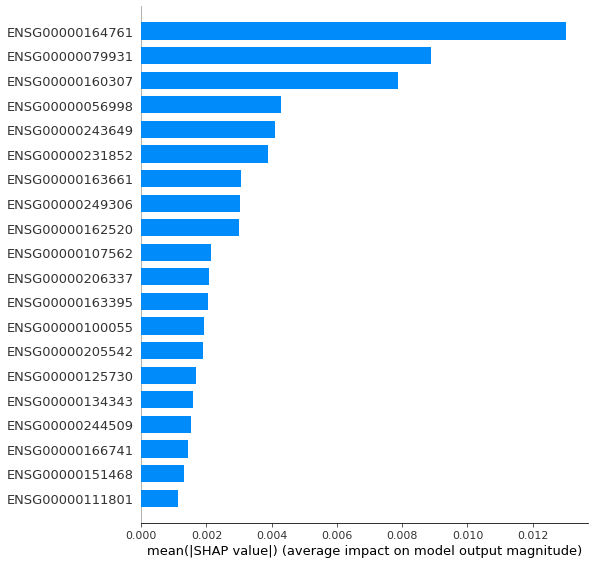

In [12]:
# Bar chart of mean importance
shap.summary_plot(shap_values, X, plot_type="bar")

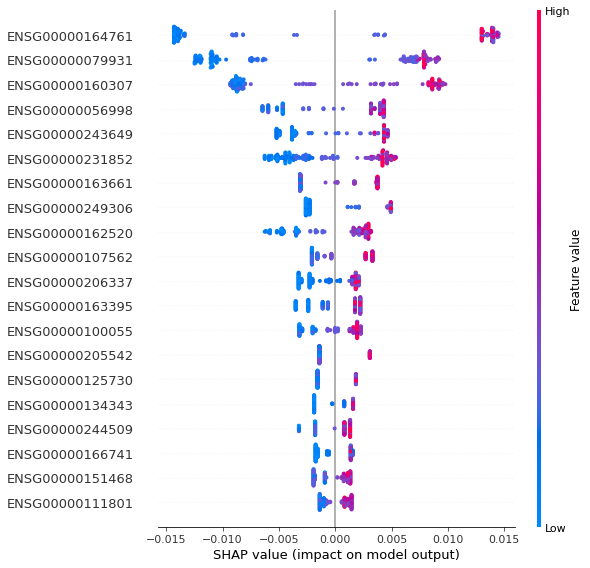

In [13]:
# Summary plot
shap.summary_plot(shap_values, X)